## Chapter 3: Sparsity and Compressed Sensing

### Overview

- Many high-dimensional datasets are actually governed by a relatively small number of important features.
- A signal is **sparse** if most of its coefficients are zero, or approximately zero, in some representation.
- Sparsity allows us to:
  - compress data
  - reconstruct signals from surprisingly few measurements
  - identify important variables in regression
  - separate structured data from corruption/noise
  - determine where measurements or sensors should be placed
- A recurring idea in this chapter is:

> Find the simplest/sparsest representation that is still consistent with the data.

- Sparsity is closely related to Occam's razor: among many explanations of the data, prefer one using relatively few active components.

### Section 3.1: Sparsity and Compression

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [4]:
A = imread(r"C:\Users\saami\OneDrive\Desktop\ML & Dynamical Systems Code\data\Book_Data\jelly.jpg")
B = np.mean(A, -1) #Convert image to grayscale (takes average of last column which contains R G B values)

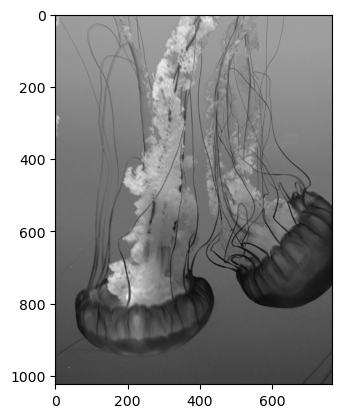

In [5]:
plt.imshow(B, cmap = 'gray')

In [6]:
## Compute FFT of image using fft2 (2-dimensional fast fourier transform)

Bhat = np.fft.fft2(B)

## Zero out all small coefficients and inverse transform
Bhatsort = np.sort(np.abs(np.reshape(Bhat, -1)))
keep = 0.05
thresh = Bhatsort[int(np.floor((1-keep)*len(Bhatsort)))]
ind = np.abs(Bhat) > thresh

Bhatcompress = Bhat * ind
Bcompress = np.fft.ifft2(Bhatcompress).astype('uint8')

C:\Users\saami\AppData\Local\Temp\ipykernel_18364\2279949959.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  Bcompress = np.fft.ifft2(Bhatcompress).astype('uint8')


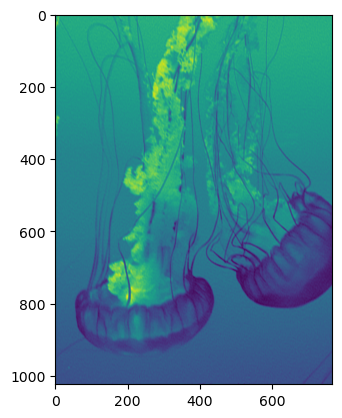

In [7]:
plt.imshow(Bcompress)

### Section 3.3: Compressed Sensing Examples

In [8]:
# Solutions to under-determined linear system y = (Theta) * s

#!pip install scipy

from scipy.optimize import minimize

# Solve y = Theta * s for "s"

n = 1000 # dimension of s
p = 200 # number of measurements, dim(y)
Theta = np.random.randn(p, n)
y = np.random.randn(p)

In [9]:
# L1 Minimum norm solution s_L1
def L1_norm(x):
    return np.linalg.norm(x, ord = 1)

constr = {'type': 'eq', 'fun' : lambda x : Theta @ x - y}
x0 = np.linalg.pinv(Theta) @ y # Initialize with L2 solution

res = minimize (L1_norm, x0, method = 'SLSQP', constraints = constr)

x_L1 = res.x

In [10]:
!pip install cosamp
from cosamp.cosamp import cosamp

In [11]:
#Compressed sensing of two tone cosine signal

## Generate signal, DCT of signal
n = 4096 # points in high resolution signal
t = np.linspace(0, 1, n)

x = np.cos(2 * 97 * np.pi * t) + np.cos(2 * 777 * np.pi * t)
xt = np.fft.fft(x) # Fourier transformed signal
PSD = xt * np.conj(xt) / n # Power spectral density

## Randomly sample signal

p = 128 # number of random samples, p = n/32
perm = np.floor(np.random.rand(p) * n).astype(int)
y = x[perm]

In [12]:
# Solve compressed sensing problem
from scipy.fft import dct, idct

Psi = dct(np.identity(n)) # Build psi
Theta = Psi[perm, :]
# CS via matching pursuit
s = cosamp(Theta, y, 10, tol=1e-10, max_iter = 10)
xrecon = idct(s) # reconstruct full signal

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10


### Section 3.5: Sparse Regression

In [17]:
# Use of l1 norm for robust statistical regression

from scipy.optimize import minimize

x = np.sort(4 * (np.random.rand(25, 1) - 0.5), axis = 0) #data
b = 0.9 * x + 0.1 * np.random.randn(len(x), 1) # Noisy line y= ax
atrue = np.linalg.lstsq(x, b, rcond = None) [0] # Least-squares a

b[-1] = -5.5 # Introduce outlier
acorrupt = np.linalg.lstsq(x, b, rcond = None) [0] # New slope

## L1 optimization to reject outlier
def L1_norm(a):
    return np.linalg.norm(a*x-b, ord=1)

a0 = acorrupt # initialize to L2 solution
res = minimize(L1_norm, x0 = a0[0])
aL1 = res.x[0] #aL1 is robust

In [14]:
# Implementing the LASSO and associated analysis functions are also simple

from sklearn import linear_model
from sklearn import model_selection

plt.rcParams['figure.figsize'] = [7, 7]
plt.rcParams.update({'font.size': 18})

A = np.random.randn(100,10) # Matrix of possible predictors
x = np.array([0, 0, 1, 0, 0, 0, -1, 0, 0, 0]) #Two nonzero predictors
b = A @ x + 2*np.random.randn(100)

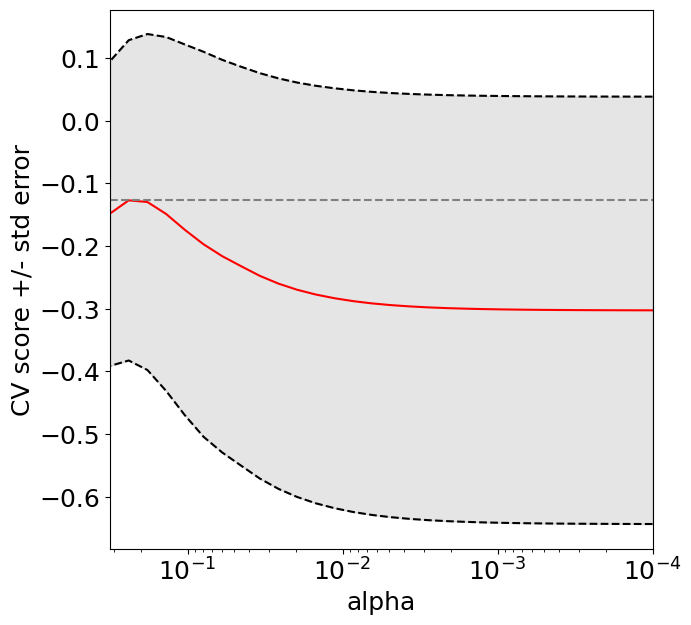

In [15]:
#Here's the actual graph of the cross-validated MSE of the Lasso fit
reg = linear_model.LassoCV(cv=10).fit(A, b)

lasso = linear_model.Lasso(random_state=0, max_iter=10000)
alphas = np.logspace(-4, -0.5, 30)

tuned_parameters = [{'alpha': alphas}]

clf = model_selection.GridSearchCV(lasso, tuned_parameters, cv=10, refit=False)
clf.fit(A, b)

scores = clf.cv_results_['mean_test_score']
scores_std = clf.cv_results_['std_test_score']
plt.semilogx(alphas, scores,'r-')

# plot error lines showing +/- std. errors of the scores
std_error = scores_std / np.sqrt(10)

plt.semilogx(alphas, scores + std_error, 'k--')
plt.semilogx(alphas, scores - std_error, 'k--')
plt.fill_between(alphas, scores + std_error, scores - std_error, alpha=0.1,color='k')

plt.ylabel('CV score +/- std error')
plt.xlabel('alpha')
plt.axhline(np.max(scores), linestyle='--', color='.5')
plt.xlim([alphas[-1], alphas[0]])

plt.show()

In [16]:
XL1 = linear_model.Lasso(alpha=clf.best_params_['alpha'])
XL1.fit(A,b)
xL1 = XL1.coef_
xL1DeBiased = np.linalg.pinv(A[:,np.abs(xL1)>0]) @ b

### Section 3.7: Robust Principal Component Analysis (RPCA)

In [ ]:
# Moving onto defining the shrink function, which is primarily used in the Lagrangian which helps with an optimization problem involving 
# finding principal components with strong explanatory power and minimizing the amount of error in the sparse matrix
# This process is known as Principal Component Pursuit

def shrink(X, tau):
    Y = np.abs(x) - tau
    return np.sign(X) * np.maximum(Y, np.zeros_like(Y))


In [19]:
# Building Singular Value Threshold function

def SVT (X, tau):
    U, S, VT = np.linalg.svd(X, full_matrices = 0)
    out = U @ np.diag(shrink(S, tau)) @ VT
    return out

In [20]:
# RPCA using alternating directions method (ADM), to be put in

### Section 3.8: Sparse Sensor Placement

In [21]:
#Example, will put in later